# Árboles
Los **árboles de decisión** son modelos predictivos utilizados tanto para tareas de clasificación como de regresión en el aprendizaje supervisado. Su estructura se asemeja a un árbol, donde cada nodo interno representa una pregunta o condición sobre una variable de entrada, cada rama corresponde a una respuesta posible, y cada hoja representa una predicción o resultado final.

Su nombre proviene de su estructura, que se asemeja a un diagrama de flujo o un árbol invertido, y se utiliza tanto para problemas de clasificación como de regresión.

Un árbol de decisión divide recursivamente el espacio de características en regiones homogéneas respecto a la variable objetivo. El proceso de construcción consiste en seleccionar, en cada nodo, la variable y el umbral que mejor separan los datos según algún criterio de pureza (por ejemplo, *Gini*, *entropía* para clasificación, o *varianza* para regresión).

Los modelos de árboles de decisión se engloban dentro de una clase conocida como algoritmos **CART** (Classification and Regression Trees).

**Concepto y Estructura: La Lógica de la Pregunta**

El objetivo principal de un Árbol de Decisión es aprender una secuencia de preguntas tipo "SI ESTO, ENTONCES AQUELLO" que conduzcan a la predicción correcta de la manera más eficiente posible. El algoritmo construye esta estructura jerárquica dividiendo el conjunto de datos de entrada en subconjuntos cada vez más "puros" o homogéneos.

### Elementos Clave del Árbol

La estructura de un árbol permite representar una lógica de decisión clara:

| Elemento | Descripción |
|---|---|
| **Nodo Raíz** (Root Node) | El punto de partida que contiene todo el conjunto de datos. La primera división importante se realiza aquí. |
| **Nodos de Decisión** (Decision Nodes) | Puntos intermedios donde se evalúa una condición o "test" sobre un atributo (p. ej., "¿Es la Edad menor que 12?"). |
| **Ramas/Sub-árboles** | Conectan los nodos de decisión y representan el camino que se toma al responder la pregunta. |
| **Nodos Terminales** o **Hojas** (Leaf Nodes) | Los nodos finales que no se dividen más. Contienen la predicción final o la etiqueta de clasificación (p. ej., "Sobrevive" o "No Sobrevive"). |


### Funcionamiento: La Búsqueda de la Pureza

Cuando el algoritmo construye el árbol, debe decidir, entre todos los atributos de entrada (como edad, sexo, ingreso, etc.), cuál es el mejor para dividir los datos en cada etapa. El "mejor" atributo es aquel que logra la partición más limpia o pura, minimizando la incertidumbre sobre la categoría de la salida.

Para lograr esto, el algoritmo utiliza medidas de **impureza** para evaluar la calidad de cada posible división. Las dos métricas más comunes son el **Índice de Gini** y la **Ganancia de Información** (basada en Entropía)

### Modelo Matemático: El Índice de Gini

El Índice de Gini mide la probabilidad de que un elemento elegido al azar de un subconjunto sea clasificado incorrectamente si su clase se selecciona aleatoriamente en proporción a la distribución de clases en ese subconjunto.

• Objetivo: El algoritmo busca elegir divisiones que **minimicen** el Índice de Gini. Un valor de 0 indica una pureza total (todos los elementos pertenecen a una sola clase), mientras que un valor más cercano a 1 (o 0.5 para clasificación binaria) indica una mezcla de clases.

El Índice de Gini se calcula mediante la siguiente fórmula:
$$
Gini=1− \sum_{i=1} ^n (p_{i})^2
$$

Argumentos de la Fórmula:

- $n$: La cantidad de clases posibles (p. ej., si el problema es binario, n=2).

- $p_{i}$ : La probabilidad (o proporción) de que un objeto pertenezca a la clase particular $i$.

- Proceso: Al calcular el Gini para cada posible división, el algoritmo elige la característica y el valor de corte que resulten en la mayor reducción de la impureza (es decir, el menor valor de Gini ponderado en los nodos hijos)

### **Formalización matemática:**

Para clasificación, el árbol busca particiones que minimicen una función de impureza $I$ en cada nodo $t$:

$$
I(t) = \sum_{k=1}^K p_{k}(1 - p_{k})
$$

donde $p_{k}$ es la proporción de muestras de la clase $k$ en el nodo $t$ (índice de Gini).  
Para regresión, se suele minimizar la suma de los errores cuadrados (varianza):

$$
I(t) = \frac{1}{N_t} \sum_{i \in t} (y_i - \bar{y}_t)^2
$$

donde $N_t$ es el número de muestras en el nodo $t$ y $\bar{y}_t$ es el valor medio de la variable objetivo en ese nodo.

El árbol se construye de manera recursiva hasta que se cumple un criterio de parada (profundidad máxima, número mínimo de muestras, etc.).

## Ventajas 
**Fácil Interpretación**: Pueden visualizarse como diagramas de flujo simples, lo que facilita explicar el resultado a personas sin conocimientos técnicos.

**No Paramétrico**: No se hacen suposiciones sobre la distribución subyacente de los datos.

**Rápido**: Son relativamente rápidos de entrenar y de usar para predecir nuevos datos.

**Manejo de Datos**: Pueden manejar datos categóricos y numéricos eficientemente y son útiles incluso con conjuntos de datos incompletos.

## Desventajas
**Propenso al Sobreajuste (Overfitting)**: Si el árbol crece demasiado (mucha profundidad), puede memorizar el ruido y los detalles específicos del conjunto de entrenamiento y fallar al generalizar.

**Sensibilidad**: Pequeños cambios en los datos de entrada pueden causar grandes cambios en la estructura del árbol, afectando las predicciones.

**No Globalmente Óptimo**: Los árboles se construyen utilizando una estrategia "voraz" (greedy), lo que significa que eligen la mejor división localmente, pero esto no garantiza que la estructura final sea la mejor globalmente.

**Fronteras de Decisión**: Tienden a crear fronteras de decisión cuadradas o rectilíneas, lo que puede ser ineficiente para modelar relaciones no lineales suaves.

#### Ejemplo de uso en Python (clasificación):
Un ejemplo clásico es predecir la supervivencia en el desastre del Titanic, donde las decisiones se basan en atributos discretos y continuos como la edad y el sexo.

Utilizamos la librería scikit-learn en Python para construir el árbol. En este ejemplo, el árbol se entrena para decidir si un pasajero sobrevive (Sí) o no (No), basándose en el sexo y la edad.

1. **Preparación de Datos**: Se definen los atributos de entrada (X) y el resultado esperado (y). (Asumimos que 'Sex_male' ha sido codificado como 0 o 1).
2. **Construcción y Entrenamiento**: Se importa la clase DecisionTreeClassifier y se ajusta el modelo a los datos de entrenamiento

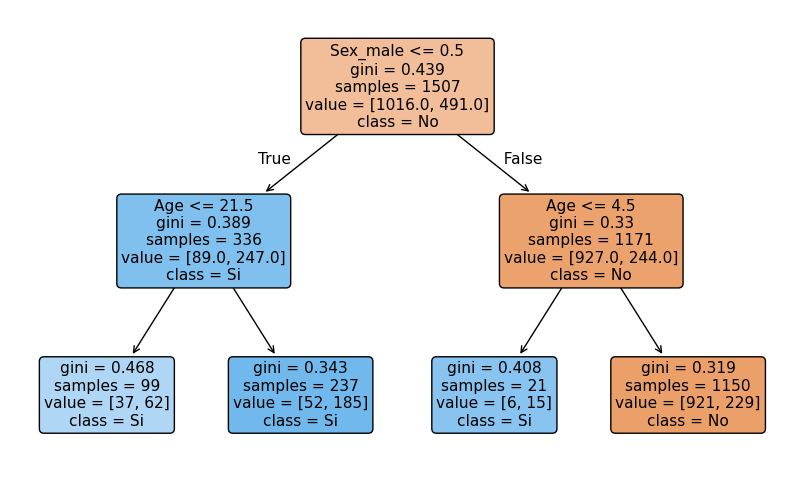

In [10]:
# EJEMPLO CONCEPTUAL EN PYTHON USANDO SCIKIT-LEARN

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/titanic5_price_clean.csv')
df = df[['Survived', 'Age', 'Sex']].dropna(subset=['Survived', 'Age', 'Sex'])

# Codificar sexo (male=1, female=0)
# Si 'Sex' ya está codificado como 0/1, el mapeo dará NaN; rellenamos con el valor original en ese caso.
df['Sex_male'] = df['Sex'].map({'male': 1, 'female': 0})
df['Sex_male'] = df['Sex_male'].fillna(df['Sex']).astype(float)

# Simulación de datos: [Edad, Sexo (1=Masculino, 0=Femenino)]
# En un caso real, esto provendría del dataset de Titanic
X_data = df[['Age', 'Sex_male']].values
# Etiquetas: 1=Sobrevive, 0=No Sobrevive
y_labels = df['Survived'].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(X_data, y_labels, test_size=0.3, random_state=42)

# --- Crear y Entrenar el Modelo ---
# Limitamos la profundidad para evitar el sobreajuste (max_depth=2) [15]
clf = DecisionTreeClassifier(criterion='gini', max_depth=2, random_state=0)
clf.fit(X_train, y_train) 

# --- Visualización del Árbol ---
# plot_tree fue importado de sklearn.tree arriba.
plt.figure(figsize=(10,6))
# X_data es un numpy.ndarray, no tiene .columns => pasamos los nombres de las características explícitamente
plot_tree(clf, feature_names=['Age', 'Sex_male'], class_names=['No', 'Si'], filled=True, rounded=True)
plt.show()
# Esta función generaría un diagrama donde se ve:
# 1. El nodo raíz dividiendo por 'Sex_male' (porque es el atributo más importante, como se ve en el ejemplo real) [5].
# 2. Las siguientes divisiones basadas en 'Age'.

Accuracy: 0.678516228748068
              precision    recall  f1-score   support

           0       0.68      0.98      0.80       437
           1       0.55      0.06      0.10       210

    accuracy                           0.68       647
   macro avg       0.61      0.52      0.45       647
weighted avg       0.64      0.68      0.58       647



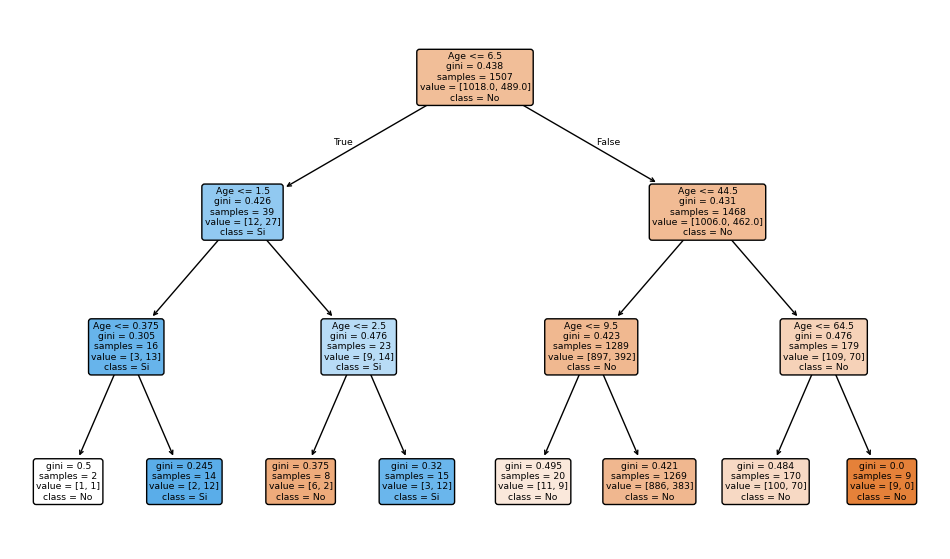

In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Cargar y preparar datos
df = pd.read_csv('../data/titanic5_price_clean.csv')
df = df[['Survived', 'Age', 'Sex']].dropna(subset=['Survived', 'Age', 'Sex'])

# Codificar sexo (male=1, female=0)
df['Sex_male'] = df['Sex'].map({'male': 1, 'female': 0})

# Características y etiqueta
X_t = df[['Age', 'Sex_male']].values
y_t = df['Survived'].astype(int).values

# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(X_t, y_t, test_size=0.3, random_state=42, stratify=y_t)

# Entrenar árbol de decisión
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0)
clf.fit(X_train, y_train)

# Evaluación
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Visualizar árbol

plt.figure(figsize=(12,7))
plot_tree(clf, feature_names=['Age','Sex_male'], class_names=['No','Si'], filled=True, rounded=True)
plt.show()
# El árbol resultante mostraría cómo las decisiones se basan en estos atributos para predecir la supervivencia

#### Ejemplo de uso en Python (regresión):

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Datos de ejemplo

X = np.array([[1], [2], [3], [4], [5]])
y = np.array([1.2, 1.9, 3.0, 3.9, 5.1])

# Entrenamiento del árbol

reg = DecisionTreeRegressor()
reg.fit(X, y)

# Predicción

print(reg.predict([[3.5]]))  # Salida aproximada: [3.0 o 3.9]

## Aplicaciones comunes

- Diagnóstico médico (clasificación de enfermedades)
- Detección de fraude
- Predicción de abandono de clientes (*churn*)
- Segmentación de clientes en marketing
- Predicción de precios de viviendas (regresión)

Los árboles de decisión son la base de algoritmos más avanzados como Random Forest y Gradient Boosting. Su principal ventaja es la interpretabilidad y facilidad de visualización, aunque pueden sobreajustar si no se podan o regulan adecuadamente.